In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# ---------------------- CUSTOM PARAMETERS ----------------------
OUTPUT_DIR = "images"
#FONT_SANS_SERIF = 'Arial'
#FONT_FAMILY = 'DejaVu Sans'
FONT_SIZE_GLOBAL = 12
FONT_SIZE_AXIS = 12
FONT_SIZE_TICKS = 12
FONT_SIZE_TITLE = 12

DATASETS = ['BMMC(44321)','PBMC(21445)','Immune(20783)','Lung(7674)']
COLOR_OURS = '#6f3995'
COLOR_SCGPT = "#8faad7"
BAR_WIDTH = 0.35
BAR_GAP = 0
LINE_WIDTH = 3
MARKER_SIZE = 8
PLOT_FIGSIZE = (9, 4.9)
DPI_VALUE = 300
ALPHA_VALUE = 0.8

In [2]:
#plt.rcParams['font.sans-serif'] = [FONT_SANS_SERIF]
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = FONT_SIZE_GLOBAL
#plt.rcParams['font.family'] = FONT_FAMILY

In [3]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [4]:
data = {
    'dataset': ['BMMC(44321)', 'BMMC(44321)',
                'PBMC(21445)', 'PBMC(21445)',
                'Immune(20783)', 'Immune(20783)',
                'Lung(7674)', 'Lung(7674)'],
    'method': ['ours', 'scgpt']*4,
    'memory': [5703,17309, 6145,17355, 5733,17307, 5639,17309],
    'speed': [1600.04,197.86, 4204.90,404.62, 1517.01,190.67, 582.25,72.30]
}
df = pd.DataFrame(data)

In [5]:
x = np.arange(len(DATASETS))

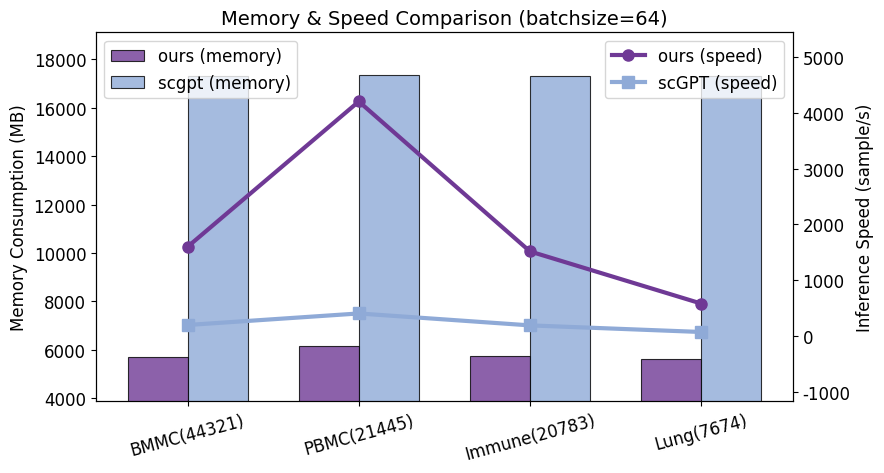

In [6]:
fig, ax1 = plt.subplots(figsize=PLOT_FIGSIZE)

# Left Y-axis: Memory (Bar)
mem_ours = df[df.method == 'ours']['memory'].values
mem_scgpt = df[df.method == 'scgpt']['memory'].values

ax1.bar(
    x - BAR_WIDTH/2 - BAR_GAP/2,
    mem_ours,
    BAR_WIDTH,
    label='ours (memory)',
    color=COLOR_OURS,
    alpha=ALPHA_VALUE,
    edgecolor='black',
    linewidth=0.8
)
ax1.bar(
    x + BAR_WIDTH/2 + BAR_GAP/2,
    mem_scgpt,
    BAR_WIDTH,
    label='scgpt (memory)',
    color=COLOR_SCGPT,
    alpha=ALPHA_VALUE,
    edgecolor='black',
    linewidth=0.8
)
ax1.set_ylabel('Memory Consumption (MB)', fontsize=FONT_SIZE_AXIS)
ax1.tick_params(axis='y')

# Expand left y-axis range
mem_all = np.concatenate([mem_ours, mem_scgpt])
mem_min, mem_max = mem_all.min(), mem_all.max()
mem_margin = (mem_max - mem_min) * 0.15 if mem_max > mem_min else mem_max * 0.15
ax1.set_ylim(mem_min - mem_margin, mem_max + mem_margin)

# Right Y-axis: Speed (Line + Marker)
ax2 = ax1.twinx()
speed_ours = df[df.method == 'ours']['speed'].values
speed_scgpt = df[df.method == 'scgpt']['speed'].values

ax2.plot(
    x, speed_ours, 'o-',
    color=COLOR_OURS,
    linewidth=LINE_WIDTH,
    markersize=MARKER_SIZE,
    label='ours (speed)'
)
ax2.plot(
    x, speed_scgpt, 's-',
    color=COLOR_SCGPT,
    linewidth=LINE_WIDTH,
    markersize=MARKER_SIZE,
    label='scGPT (speed)'
)
ax2.set_ylabel('Inference Speed (sample/s)', fontsize=FONT_SIZE_AXIS)
ax2.tick_params(axis='y')

# Expand right y-axis range
speed_all = np.concatenate([speed_ours, speed_scgpt])
speed_min, speed_max = speed_all.min(), speed_all.max()
speed_margin = (speed_max - speed_min) * 0.3 if speed_max > speed_min else speed_max * 0.3
ax2.set_ylim(speed_min - speed_margin, speed_max + speed_margin)

# Global Style
ax1.set_xticks(x)
ax1.set_xticklabels(DATASETS, rotation=15, fontsize=FONT_SIZE_TICKS)
ax1.set_title('Memory & Speed Comparison (batchsize=64)', fontsize=14)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()

# Save and Show
plt.savefig(os.path.join(OUTPUT_DIR, 'speed_memory.png'), dpi=DPI_VALUE, bbox_inches='tight')
plt.show()
plt.close()

In [7]:
print("Speed and memory plot saved to:", OUTPUT_DIR)

Speed and memory plot saved to: images
